In [ ]:

# CELL 1  Install

import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'timm'])
print('Done ✅')

Done ✅


In [ ]:
# CELL 2 — Imports

import os, random, math, warnings, glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'albumentations : {A.__version__}')
print(f'PyTorch        : {torch.__version__}')
print(f'Device         : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

albumentations : 2.0.8
PyTorch        : 2.10.0+cu128
Device         : cuda
GPU            : Tesla T4
VRAM           : 15.6 GB


In [ ]:
# CELL 3 — Config

from pathlib import Path

# ── Paths ────────────────────────────────────────────────────

DATA_DIR = "/kaggle/input/competitions/emotion-detection-competition/Training_data/Training_data"

TEST_DIR = "/kaggle/input/competitions/emotion-detection-competition/test/test"

TRAIN_DIR = Path(DATA_DIR)
TEST_DIR  = Path(TEST_DIR)

CKPT_PATH  = '/kaggle/working/best_model.pt'
OUTPUT_CSV = Path('/kaggle/working/submission.csv')

print(f'  TRAIN_DIR : {TRAIN_DIR}')
print(f'  TEST_DIR  : {TEST_DIR}')

# ── Classes ──────────────────────────────────────────────────

CLASSES = [
    'angry',
    'disgust',
    'fear',
    'happy',
    'sad',
    'surprise'
]

NUM_CLASSES = len(CLASSES)

CLS2IDX = {c: i for i, c in enumerate(CLASSES)}

# ── Data ─────────────────────────────────────────────────────

IMG_SIZE   = 224
BATCH_SIZE = 64
VAL_SPLIT  = 0.15

# ── Phase 1 ──────────────────────────────────────────────────

P1_EPOCHS = 20
P1_LR     = 1e-3

# ── Phase 2 ──────────────────────────────────────────────────

P2_EPOCHS     = 50
P2_HEAD_LR    = 6e-5
LLRD_FACTOR   = 0.65
WARMUP_EPOCHS = 4
UNFREEZE_FROM = 2

# ── Regularisation ───────────────────────────────────────────

DROPOUT      = 0.45
LABEL_SMOOTH = 0.10
MIXUP_ALPHA  = 0.1

# ── AMP ──────────────────────────────────────────────────────

USE_AMP = True

print('Config ')
print(f'  Number of classes : {NUM_CLASSES}')
print(f'  Phase 1 : {P1_EPOCHS} epochs | LR={P1_LR}')
print(f'  Phase 2 : {P2_EPOCHS} epochs | HeadLR={P2_HEAD_LR}')

  TRAIN_DIR : /kaggle/input/competitions/emotion-detection-competition/Training_data/Training_data
  TEST_DIR  : /kaggle/input/competitions/emotion-detection-competition/test/test
Config ✅
  Number of classes : 6
  Phase 1 : 20 epochs | LR=0.001
  Phase 2 : 50 epochs | HeadLR=6e-05


In [ ]:

# CELL 4 — Augmentation (albumentations 2.x) — BRIGHTNESS/CONTRAST FOCUS

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfm = A.Compose([

    # ── 1. GEOMETRY — minimal, keep face intact ────────────────
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),
        scale=(0.85, 1.0),
        ratio=(0.95, 1.05),
        p=1.0
    ),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, border_mode=0, p=0.30),

    # ── 2. BRIGHTNESS / CONTRAST — main focus ─────────────────
    # Simulate dark test images
    A.RandomBrightnessContrast(
        brightness_limit=(-0.40, 0.20),
        contrast_limit=(-0.20, 0.40),
        p=0.90
    ),

    # Gamma: makes image darker or brighter non-linearly
    A.RandomGamma(gamma_limit=(60, 150), p=0.70),

    # CLAHE: fixes low-contrast / flat images
    A.CLAHE(clip_limit=4.0, tile_grid_size=(4, 4), p=0.50),

    # Equalize: strong contrast fix
    A.Equalize(p=0.30),

    # ToGray: test images often near-grayscale
    A.ToGray(p=0.20),

    # ── 3. LIGHT NOISE ONLY ───────────────────────────────────
    A.GaussNoise(std_range=(0.01, 0.05), p=0.20),

    # ── 4. NORMALIZE + TENSOR ─────────────────────────────────
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_tfm = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

print('Transforms built ✅')
print(f'  Train pipeline : {len(train_tfm.transforms)} top-level stages')
print(f'  Val pipeline   : {len(val_tfm.transforms)} stages (no aug)')

Transforms built ✅
  Train pipeline : 11 top-level stages
  Val pipeline   : 3 stages (no aug)


In [ ]:

# CELL 5 — Datasets & DataLoaders

class EmotionDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None,
                 split='train', val_split=0.15, seed=42):
        self.transform = transform
        self.samples   = []
        rng = random.Random(seed)
        for cls in classes:
            folder = Path(root_dir) / cls
            imgs   = sorted(folder.glob('*.jpg')) + sorted(folder.glob('*.png'))
            imgs   = [str(p) for p in imgs]
            rng.shuffle(imgs)
            cut    = int(len(imgs) * val_split)
            chosen = imgs[:cut] if split == 'val' else imgs[cut:]
            self.samples.extend([(p, CLS2IDX[cls]) for p in chosen])
        print(f'  {split:5s}: {len(self.samples)} samples')

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.array(Image.open(path).convert('RGB'))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label


class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        # Search recursively one level deep to handle nested test folders
        test_dir = Path(test_dir)
        raw = (glob.glob(str(test_dir / "*.jpg")) +
               glob.glob(str(test_dir / "*.png")) +
               glob.glob(str(test_dir / "*.jpeg")) +
               glob.glob(str(test_dir / "**" / "*.jpg")) +
               glob.glob(str(test_dir / "**" / "*.png")))
        raw = list(set(raw))   # deduplicate
        # Sort: try numeric stem first, fallback to alphabetic
        def _key(p):
            stem = Path(p).stem
            # strip any surrounding text and grab embedded number
            import re
            m = re.search(r"(\d+)", stem)
            return int(m.group(1)) if m else stem
        self.paths     = sorted(raw, key=_key)
        self.transform = transform
        print(f"  Test dir    : {test_dir}")
        print(f"  Test images : {len(self.paths)}")
        if len(self.paths) == 0:
            print(f"  ⚠️  No images found! Contents: {list(test_dir.iterdir()) if test_dir.exists() else 'DIR NOT FOUND'}")

    def __len__(self):  return len(self.paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.paths[idx]).convert("RGB"))
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, Path(self.paths[idx]).name


print('Building datasets...')
train_ds = EmotionDataset(TRAIN_DIR, CLASSES, train_tfm, split='train', val_split=VAL_SPLIT)
val_ds   = EmotionDataset(TRAIN_DIR, CLASSES, val_tfm,   split='val',   val_split=VAL_SPLIT)

# Weighted sampler — fixes class imbalance at batch level
labels_flat    = [lbl for _, lbl in train_ds.samples]
cw_array       = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=labels_flat)
sample_weights = torch.tensor([cw_array[lbl] for _, lbl in train_ds.samples], dtype=torch.float)
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train batches : {len(train_loader)}  |  Val batches: {len(val_loader)}')
print(f'Class weights : {[f"{c}:{cw_array[i]:.2f}" for i,c in enumerate(CLASSES)]}')

Building datasets...
  train: 28253 samples
  val  : 4984 samples
Train batches : 441  |  Val batches: 78
Class weights : ['angry:1.23', 'disgust:1.23', 'fear:1.23', 'happy:0.57', 'sad:1.10', 'surprise:1.10']


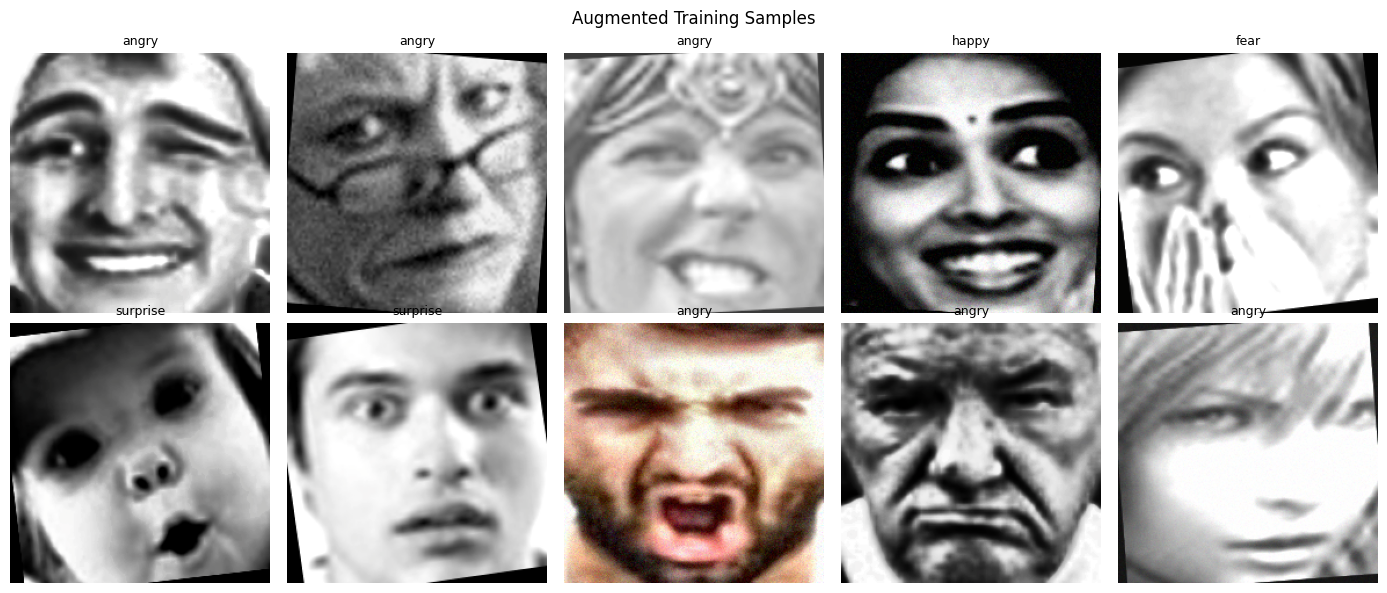

In [ ]:

# CELL 6 — Preview augmented samples
 
def denormalise(t):
    m = torch.tensor(MEAN).view(3,1,1)
    s = torch.tensor(STD).view(3,1,1)
    return (t.cpu()*s+m).clamp(0,1).permute(1,2,0).numpy()

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, img, lbl in zip(axes.flat, imgs[:10], labels[:10]):
    ax.imshow(denormalise(img)); ax.set_title(CLASSES[lbl.item()], fontsize=9); ax.axis('off')
plt.suptitle('Augmented Training Samples'); plt.tight_layout()
plt.savefig('/kaggle/working/augmented_samples.png', dpi=150); plt.show()

In [ ]:
 
# CELL 7 — Model (EfficientNetV2-S FROM SCRATCH 
import torch
import torch.nn as nn
import torch.nn.functional as F

class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()  
        return x.div(keep_prob) * random_tensor

class ConvBN(nn.Module):
    def __init__(self, in_c, out_c, kernel_size, stride=1, groups=1):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(in_c, out_c, kernel_size, stride, padding, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(out_c, momentum=0.1, eps=1e-3)
        
    def forward(self, x):
        return self.bn(self.conv(x))

class SEBlock(nn.Module):
    def __init__(self, in_c, se_ratio=0.25):
        super().__init__()
        num_reduced = max(1, int(in_c * se_ratio))
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_c, num_reduced, 1, bias=True),
            nn.SiLU(inplace=True),
            nn.Conv2d(num_reduced, in_c, 1, bias=True),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return x * self.se(x)

class FusedMBConv(nn.Module):
    def __init__(self, in_c, out_c, expansion, stride, drop_path_rate):
        super().__init__()
        self.use_skip = (stride == 1 and in_c == out_c)
        exp_c = in_c * expansion
        
        # expansion==1: fused single conv (in→out), no project step
        self.expand_conv = ConvBN(in_c, exp_c, 3, stride=stride)
        self.project_conv = ConvBN(exp_c, out_c, 1) if expansion != 1 else nn.Identity()
        self.act = nn.SiLU(inplace=True)
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate > 0 else nn.Identity()

    def forward(self, x):
        out = self.act(self.expand_conv(x))
        if not isinstance(self.project_conv, nn.Identity):
            out = self.project_conv(out)  # linear projection, no activation
        if self.use_skip:
            out = x + self.drop_path(out)
        return out

class MBConv(nn.Module):
    def __init__(self, in_c, out_c, expansion, stride, drop_path_rate, se_ratio=0.25):
        super().__init__()
        self.use_skip = (stride == 1 and in_c == out_c)
        exp_c = in_c * expansion
        
        self.expand_conv = nn.Sequential(ConvBN(in_c, exp_c, 1), nn.SiLU(inplace=True)) if expansion != 1 else nn.Identity()
        self.dw_conv = nn.Sequential(ConvBN(exp_c, exp_c, 3, stride=stride, groups=exp_c), nn.SiLU(inplace=True))
        self.se = SEBlock(exp_c, se_ratio)
        self.project_conv = ConvBN(exp_c, out_c, 1)
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate > 0 else nn.Identity()

    def forward(self, x):
        out = self.expand_conv(x)
        out = self.dw_conv(out)
        out = self.se(out)
        out = self.project_conv(out)
        if self.use_skip:
            out = x + self.drop_path(out)
        return out

class EfficientNetV2S_FromScratch(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.2, survival_prob=0.8):
        super().__init__()
        
        stage_configs = [
            ('fused', 1, 1, 24, 2),
            ('fused', 4, 2, 48, 4),
            ('fused', 4, 2, 64, 4),
            ('mb', 4, 2, 128, 6),
            ('mb', 6, 1, 160, 9),
            ('mb', 6, 2, 256, 15),
        ]
        
        # STEM
        self.stem = nn.Sequential(ConvBN(3, 24, 3, stride=2), nn.SiLU(inplace=True))
        
        # STAGES
        self.blocks = nn.ModuleList()
        total_layers = sum(cfg[4] for cfg in stage_configs)
        layer_idx = 0
        in_c = 24
        
        for stage_idx, (b_type, exp, stride, out_c, num_layers) in enumerate(stage_configs):
            stage = nn.ModuleList()
            for layer in range(num_layers):
                drop_rate = (1.0 - survival_prob) * (layer_idx / total_layers)
                s = stride if layer == 0 else 1
                
                if b_type == 'fused':
                    stage.append(FusedMBConv(in_c, out_c, exp, s, drop_rate))
                else:
                    stage.append(MBConv(in_c, out_c, exp, s, drop_rate, se_ratio=0.25))
                    
                in_c = out_c
                layer_idx += 1
            self.blocks.append(stage)
            
        # HEAD
        self.neck = nn.Sequential(ConvBN(in_c, 1280, 1), nn.SiLU(inplace=True))
        self.head_gap = nn.AdaptiveAvgPool2d(1)
        self.head_dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else nn.Identity()
        self.head = nn.Linear(1280, num_classes)
        
    def forward(self, x):
        x = self.stem(x)
        for stage in self.blocks:
            for block in stage:
                x = block(x)
        x = self.neck(x)
        x = self.head_gap(x).flatten(1)
        x = self.head_dropout(x)
        return self.head(x)

    def unfreeze_blocks(self, from_block=0):
        # Freeze all
        for param in self.parameters():
            param.requires_grad = False
            
        # Unfreeze Head & Neck
        for param in self.head.parameters(): param.requires_grad = True
        for param in self.neck.parameters(): param.requires_grad = True
            
        # Unfreeze blocks starting from 'from_block'
        for i in range(from_block, len(self.blocks)):
            for param in self.blocks[i].parameters():
                param.requires_grad = True

    def get_layer_groups(self, from_block=0):
        # Generate layer groups for Layer-wise Learning Rate Decay (LLRD)
        groups = []
        groups.append({'name': 'head', 'params': list(self.head.parameters())})
        groups.append({'name': 'neck', 'params': list(self.neck.parameters())})
        
        # Add blocks in reverse order (deepest blocks get higher LR)
        for i in range(len(self.blocks)-1, from_block-1, -1):
            groups.append({'name': f'block{i}', 'params': list(self.blocks[i].parameters())})
            
        return groups


# CREATE MODEL

model = EfficientNetV2S_FromScratch(
    num_classes=NUM_CLASSES, 
    dropout_rate=DROPOUT, 
    survival_prob=0.8
).to(DEVICE)

print(f'Model Created: EfficientNetV2-S From Scratch (PyTorch) - Params: {sum(p.numel() for p in model.parameters()):,}')

Model Created: EfficientNetV2-S From Scratch (PyTorch) - Params: 38,172,558


In [ ]:
 
# CELL 8 — Training utilities
 

def mixup_data(x, y, alpha):
    if alpha <= 0: return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def mixup_criterion(crit, pred, ya, yb, lam):
    return lam*crit(pred, ya) + (1-lam)*crit(pred, yb)


def train_one_epoch(model, loader, optimizer, criterion, scaler,
                    scheduler=None, mixup_alpha=0.0, scheduler_step='batch'):
    model.train()
    total_loss = correct = n = nan_batches = 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        imgs, ya, yb, lam = mixup_data(imgs, labels, mixup_alpha)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = mixup_criterion(criterion, logits, ya, yb, lam)

        # ── NaN/Inf guard ─────────────────────────────────────────
        # If loss is NaN/Inf, skip this batch and reset the scaler
        # instead of propagating corrupted gradients through the model.
        if not torch.isfinite(loss):
            nan_batches += 1
            optimizer.zero_grad()
            scaler.update()   # advance scaler state so it can recover
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None and scheduler_step == 'batch':
            scheduler.step()

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        preds = logits.detach().argmax(1)
        correct += (lam*(preds==ya).float() + (1-lam)*(preds==yb).float()).sum().item()
        n += bs

    if nan_batches > 0:
        print(f'      Skipped {nan_batches} NaN/Inf batches this epoch')

    if n == 0:   # entire epoch was NaN — return sentinel values
        return float('nan'), 0.0
    return total_loss/n, correct/n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = correct = n = 0
    all_probs, all_labels = [], []
    crit = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(imgs)
        logits_f   = logits.float()          # cast OUTSIDE autocast
        loss       = crit(logits_f, labels)
        probs      = F.softmax(logits_f, dim=1)
        correct   += (probs.argmax(1) == labels).sum().item()
        total_loss += loss.item() * imgs.size(0)
        n          += imgs.size(0)
        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

    return total_loss/n, correct/n, torch.cat(all_probs), torch.cat(all_labels)


def cosine_lr_with_warmup(optimizer, epoch, total_epochs, warmup_epochs, base_lrs):
    """
    Manual cosine LR schedule with linear warmup.
    base_lrs: list of peak LRs matching optimizer.param_groups.
    Call once per epoch BEFORE the training step.
    """
    if epoch < warmup_epochs:
        scale = (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        scale    = 0.5 * (1.0 + math.cos(math.pi * progress))
    for pg, base_lr in zip(optimizer.param_groups, base_lrs):
        pg['lr'] = base_lr * scale


print('Utilities ready ')

Utilities ready ✅


In [ ]:
 
# CELL 9 — Phase 1: Frozen backbone, head only
 
# Strategy:
#   - Flat AdamW 1e-3 with ReduceLROnPlateau (patience=3)
#   - MixUp OFF: gives the head a clean signal to learn class boundaries
#   - 15 epochs: enough to reach 70-75% before fine-tuning starts

# Freeze all backbone params — only head trains in Phase 1
for param in model.parameters():
    param.requires_grad = False
for param in model.head.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
scaler    = torch.cuda.amp.GradScaler(enabled=USE_AMP)

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=P1_LR, weight_decay=1e-4
)
scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode='max', factor=0.5, patience=3, min_lr=1e-6
)

history      = defaultdict(list)
best_val_acc = 0.0

print('═'*60)
print('PHASE 1 — Head training (backbone frozen, MixUp OFF)')
print('═'*60)

for epoch in range(1, P1_EPOCHS + 1):
    tr_loss, tr_acc        = train_one_epoch(
        model, train_loader, optimizer_p1, criterion, scaler,
        scheduler=None, mixup_alpha=0.0  # MixUp OFF
    )
    vl_loss, vl_acc, _, _  = evaluate(model, val_loader)
    scheduler_p1.step(vl_acc)           # plateau scheduler steps on val_acc
    cur_lr = optimizer_p1.param_groups[0]['lr']

    history['phase'].append(1)
    history['loss'].append(tr_loss)
    history['accuracy'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_accuracy'].append(vl_acc)
    history['lr'].append(cur_lr)

    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)
        flag = '✅'

    print(f'Ep {epoch:02d}/{P1_EPOCHS} | '
          f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | '
          f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} | '
          f'lr={cur_lr:.2e} {flag}')

print(f'\nPhase 1 best val_acc: {best_val_acc:.4f}')

════════════════════════════════════════════════════════════
PHASE 1 — Head training (backbone frozen, MixUp OFF)
════════════════════════════════════════════════════════════
Ep 01/20 | tr_loss=1.8130 tr_acc=0.1853 | vl_loss=1.7856 vl_acc=0.1451 | lr=1.00e-03 ✅
Ep 02/20 | tr_loss=1.8143 tr_acc=0.1955 | vl_loss=1.7658 vl_acc=0.2953 | lr=1.00e-03 ✅
Ep 03/20 | tr_loss=1.8113 tr_acc=0.1973 | vl_loss=1.7897 vl_acc=0.1449 | lr=1.00e-03 
Ep 04/20 | tr_loss=1.8106 tr_acc=0.2021 | vl_loss=1.7730 vl_acc=0.2026 | lr=1.00e-03 
Ep 05/20 | tr_loss=1.8097 tr_acc=0.2016 | vl_loss=1.7813 vl_acc=0.1615 | lr=1.00e-03 
Ep 06/20 | tr_loss=1.8119 tr_acc=0.1984 | vl_loss=1.7675 vl_acc=0.2362 | lr=5.00e-04 
Ep 07/20 | tr_loss=1.8031 tr_acc=0.2015 | vl_loss=1.7678 vl_acc=0.2237 | lr=5.00e-04 
Ep 08/20 | tr_loss=1.8045 tr_acc=0.2033 | vl_loss=1.7669 vl_acc=0.2153 | lr=5.00e-04 
Ep 09/20 | tr_loss=1.7973 tr_acc=0.2002 | vl_loss=1.7664 vl_acc=0.2153 | lr=5.00e-04 
Ep 10/20 | tr_loss=1.7974 tr_acc=0.1993 | vl_loss

In [ ]:
 
# CELL 10 — Phase 2: LLRD + cosine warmup + progressive unfreeze
 
#
# Layer-wise LR Decay (LLRD) — why it matters:
#   Early layers of a pretrained backbone have learned general low-level features
#   (edges, textures). These should NOT be updated much — a tiny LR preserves them.
#   Later layers are more task-specific and need bigger updates.
#   LLRD achieves this by multiplying LR by LLRD_FACTOR for each deeper group:
#
#     head        → P2_HEAD_LR          (e.g. 5e-5)
#     neck        → 5e-5 × 0.65        = 3.25e-5
#     block5      → 5e-5 × 0.65²       = 2.11e-5
#     block4      → 5e-5 × 0.65³       = 1.37e-5
#     block3      → 5e-5 × 0.65⁴       = 8.94e-6
#
# Cosine schedule with warmup:
#   Linearly ramp all LRs from 0 → peak over WARMUP_EPOCHS,
#   then cosine decay to near-zero. Much smoother than OneCycleLR cliff.

# Load best Phase 1 weights
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

# Unfreeze blocks UNFREEZE_FROM..5 + neck (now from block 2)
model.unfreeze_blocks(from_block=UNFREEZE_FROM)

# Build LLRD param groups
layer_groups = model.get_layer_groups(from_block=UNFREEZE_FROM)
base_lrs     = [P2_HEAD_LR * (LLRD_FACTOR ** i) for i in range(len(layer_groups))]

# Attach LRs and weight_decay to each group
param_groups = []
for grp, base_lr in zip(layer_groups, base_lrs):
    param_groups.append({'params': grp['params'], 'lr': base_lr, 'name': grp['name']})

optimizer_p2 = torch.optim.AdamW(param_groups, weight_decay=1e-4)

print('\nLLRD param groups:')
for pg, blr in zip(param_groups, base_lrs):
    n_p = sum(p.numel() for p in pg['params'])
    print(f"  {pg['name']:10s} | peak_lr={blr:.2e} | params={n_p:,}")

PATIENCE     = 10
pat_counter  = 0

print('\n' + '═'*60)
print(f'PHASE 2 — LLRD + cosine warmup ({WARMUP_EPOCHS}ep) + MixUp α={MIXUP_ALPHA}')
print('═'*60)

for epoch in range(1, P2_EPOCHS + 1):
    # Apply cosine LR with warmup BEFORE each epoch
    cosine_lr_with_warmup(optimizer_p2, epoch - 1, P2_EPOCHS, WARMUP_EPOCHS, base_lrs)

    tr_loss, tr_acc        = train_one_epoch(
        model, train_loader, optimizer_p2, criterion, scaler,
        scheduler=None, mixup_alpha=MIXUP_ALPHA, scheduler_step='epoch'
    )
    vl_loss, vl_acc, _, _  = evaluate(model, val_loader)

    cur_lr = optimizer_p2.param_groups[0]['lr']   # head LR
    history['phase'].append(2)
    history['loss'].append(tr_loss)
    history['accuracy'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_accuracy'].append(vl_acc)
    history['lr'].append(cur_lr)

    flag = ''
    # Guard: only save if val_acc is sane — prevents overwriting good weights with NaN-corrupted ones
    if vl_acc > best_val_acc and vl_acc > 0.30 and not math.isnan(vl_loss):
        best_val_acc = vl_acc
        pat_counter  = 0
        torch.save(model.state_dict(), CKPT_PATH)
        flag = '✅'
    elif vl_acc <= 0.30 or math.isnan(vl_loss):
        flag = ' NaN — skipping save'
        pat_counter += 1
    else:
        pat_counter += 1

    print(f'Ep {epoch:02d}/{P2_EPOCHS} | '
          f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | '
          f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} | '
          f'lr={cur_lr:.2e} {flag}')

    if pat_counter >= PATIENCE:
        print(f'Early stop — no improvement for {PATIENCE} epochs')
        break

print(f'\nPhase 2 best val_acc : {best_val_acc:.4f}')
print(f'Overall best         : {best_val_acc*100:.2f}%')


LLRD param groups:
  head       | peak_lr=6.00e-05 | params=7,686
  neck       | peak_lr=3.90e-05 | params=330,240
  block5     | peak_lr=2.54e-05 | params=28,713,072
  block4     | peak_lr=1.65e-05 | params=6,783,360
  block3     | peak_lr=1.07e-05 | params=1,434,304
  block2     | peak_lr=6.96e-06 | params=589,184

════════════════════════════════════════════════════════════
PHASE 2 — LLRD + cosine warmup (4ep) + MixUp α=0.1
════════════════════════════════════════════════════════════
Ep 01/50 | tr_loss=1.2302 tr_acc=0.5984 | vl_loss=1.0554 vl_acc=0.6808 | lr=1.50e-05 
Ep 02/50 | tr_loss=1.2394 tr_acc=0.5910 | vl_loss=1.0437 vl_acc=0.6844 | lr=3.00e-05 ✅
Ep 03/50 | tr_loss=1.2253 tr_acc=0.6002 | vl_loss=1.0597 vl_acc=0.6796 | lr=4.50e-05 
Ep 04/50 | tr_loss=1.2454 tr_acc=0.5925 | vl_loss=1.0552 vl_acc=0.6846 | lr=6.00e-05 ✅
Ep 05/50 | tr_loss=1.2387 tr_acc=0.5932 | vl_loss=1.0549 vl_acc=0.6784 | lr=6.00e-05 
Ep 06/50 | tr_loss=1.2356 tr_acc=0.5957 | vl_loss=1.0520 vl_acc=0.6844 | lr

In [ ]:
 
# CELL 11 — Phase 3 (optional): Full backbone, very low LR
# Run if Phase 2 < 85%. Expected +2-3%.
 

RUN_PHASE3 = True   # ← set True to run

if RUN_PHASE3:
    P3_EPOCHS  = 20      # more epochs since starting from near-plateau
    P3_HEAD_LR = 3e-5    # was 1e-5 — slightly higher to escape local minimum
    WARMUP_P3  = 3

    model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

    # Fully unfreeze ALL backbone blocks
    model.unfreeze_blocks(from_block=0)
    layer_groups_p3 = model.get_layer_groups(from_block=0)
    base_lrs_p3     = [P3_HEAD_LR * (LLRD_FACTOR ** i) for i in range(len(layer_groups_p3))]

    param_groups_p3 = []
    for grp, blr in zip(layer_groups_p3, base_lrs_p3):
        param_groups_p3.append({'params': grp['params'], 'lr': blr, 'name': grp['name']})

    optimizer_p3 = torch.optim.AdamW(param_groups_p3, weight_decay=1e-4)

    print('\nPhase 3 LLRD groups:')
    for pg, blr in zip(param_groups_p3, base_lrs_p3):
        print(f"  {pg['name']:10s} | peak_lr={blr:.2e}")

    print('\n' + '═'*60)
    print('PHASE 3 — Full backbone + LLRD + cosine')
    print('═'*60)

    pat3 = 0
    for epoch in range(1, P3_EPOCHS + 1):
        cosine_lr_with_warmup(optimizer_p3, epoch-1, P3_EPOCHS, WARMUP_P3, base_lrs_p3)

        tr_loss, tr_acc       = train_one_epoch(
            model, train_loader, optimizer_p3, criterion, scaler,
            scheduler=None, mixup_alpha=MIXUP_ALPHA, scheduler_step='epoch'
        )
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader)

        history['phase'].append(3)
        history['loss'].append(tr_loss)
        history['accuracy'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_accuracy'].append(vl_acc)
        history['lr'].append(optimizer_p3.param_groups[0]['lr'])

        flag = ''
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            pat3 = 0
            torch.save(model.state_dict(), CKPT_PATH)
            flag = '✅'
        else:
            pat3 += 1

        print(f'Ep {epoch:02d}/{P3_EPOCHS} | tr_acc={tr_acc:.4f} | vl_acc={vl_acc:.4f} | '
              f'lr={optimizer_p3.param_groups[0]["lr"]:.2e} {flag}')

        if pat3 >= 8:
            print('Early stop P3')
            break

    print(f'Phase 3 best: {best_val_acc*100:.2f}%')
else:
    print('Phase 3 skipped (set RUN_PHASE3=True to run)')


Phase 3 LLRD groups:
  head       | peak_lr=3.00e-05
  neck       | peak_lr=1.95e-05
  block5     | peak_lr=1.27e-05
  block4     | peak_lr=8.24e-06
  block3     | peak_lr=5.36e-06
  block2     | peak_lr=3.48e-06
  block1     | peak_lr=2.26e-06
  block0     | peak_lr=1.47e-06

════════════════════════════════════════════════════════════
PHASE 3 — Full backbone + LLRD + cosine
════════════════════════════════════════════════════════════
Ep 01/20 | tr_acc=0.7336 | vl_acc=0.7626 | lr=1.00e-05 
Ep 02/20 | tr_acc=0.7315 | vl_acc=0.7642 | lr=2.00e-05 
Ep 03/20 | tr_acc=0.7311 | vl_acc=0.7652 | lr=3.00e-05 
Ep 04/20 | tr_acc=0.7278 | vl_acc=0.7626 | lr=3.00e-05 
Ep 05/20 | tr_acc=0.7225 | vl_acc=0.7646 | lr=2.97e-05 
Ep 06/20 | tr_acc=0.7408 | vl_acc=0.7654 | lr=2.90e-05 
Ep 07/20 | tr_acc=0.7393 | vl_acc=0.7654 | lr=2.78e-05 
Ep 08/20 | tr_acc=0.7479 | vl_acc=0.7699 | lr=2.61e-05 ✅
Ep 09/20 | tr_acc=0.7442 | vl_acc=0.7711 | lr=2.40e-05 ✅
Ep 10/20 | tr_acc=0.7462 | vl_acc=0.7679 | lr=2.17e-0

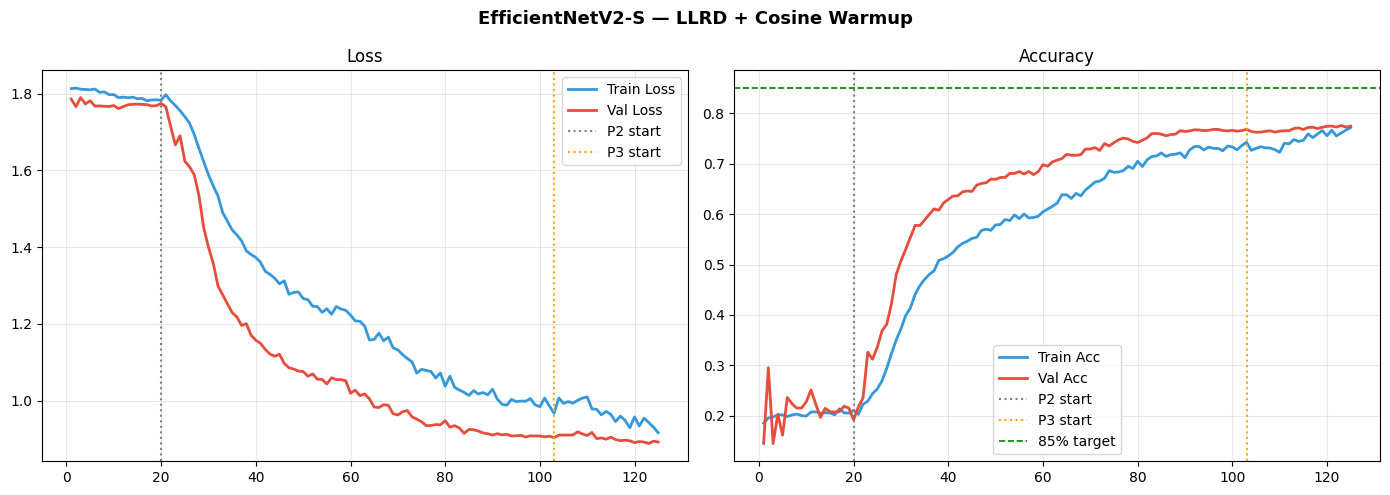


🏆 Best val accuracy: 77.59%
   Target 85% → ❌ Run Phase 3 (set RUN_PHASE3=True)


In [ ]:
 
# CELL 12 — Training curves
 
total_ep = len(history['loss'])
p1_end   = sum(1 for p in history['phase'] if p == 1)
p2_end   = sum(1 for p in history['phase'] if p in (1, 2))
ep       = range(1, total_ep + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ep, history['loss'],     lw=2, color='#3498DB', label='Train Loss')
ax.plot(ep, history['val_loss'], lw=2, color='#E74C3C', label='Val Loss')
ax.axvline(p1_end, color='gray',  ls=':', lw=1.5, label='P2 start')
if p2_end < total_ep: ax.axvline(p2_end, color='orange', ls=':', lw=1.5, label='P3 start')
ax.set_title('Loss'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ep, history['accuracy'],     lw=2, color='#3498DB', label='Train Acc')
ax.plot(ep, history['val_accuracy'], lw=2, color='#E74C3C', label='Val Acc')
ax.axvline(p1_end, color='gray',  ls=':', lw=1.5, label='P2 start')
if p2_end < total_ep: ax.axvline(p2_end, color='orange', ls=':', lw=1.5, label='P3 start')
ax.axhline(0.85, color='green', ls='--', lw=1.2, label='85% target')
ax.set_title('Accuracy'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('EfficientNetV2-S — LLRD + Cosine Warmup', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

print(f'\n Best val accuracy: {best_val_acc*100:.2f}%')

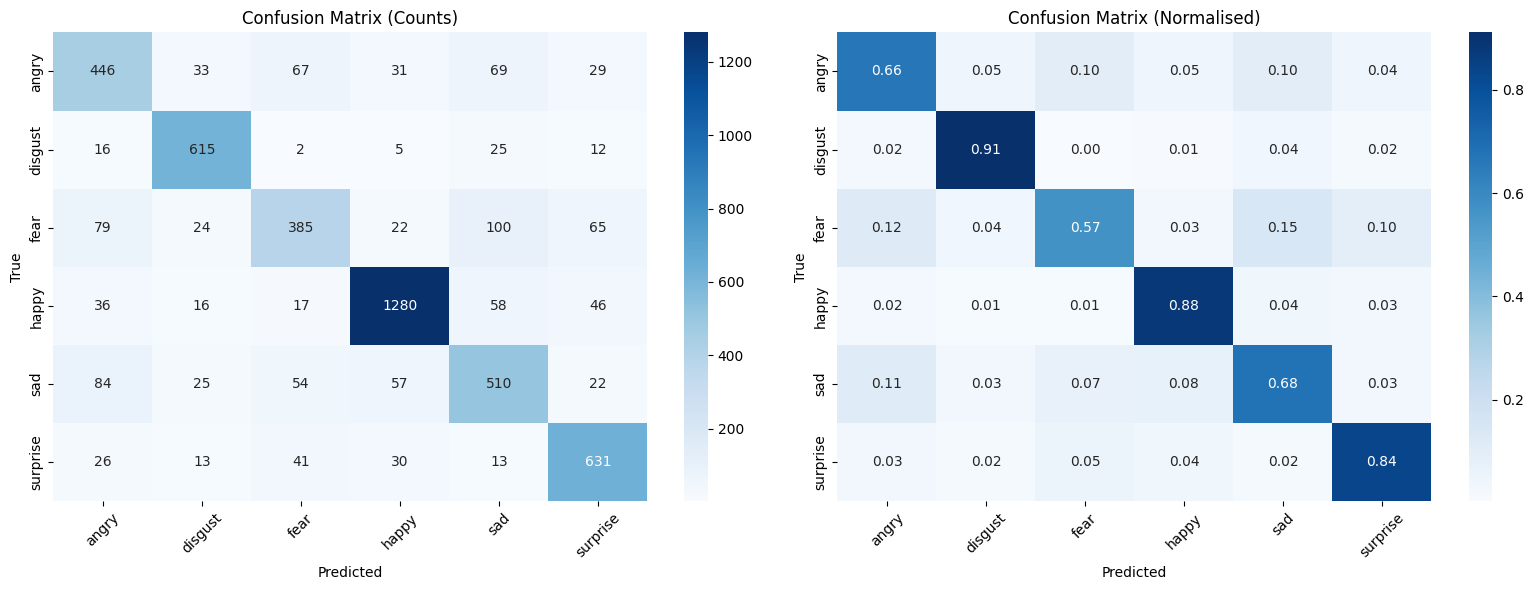

              precision    recall  f1-score   support

       angry     0.6492    0.6607    0.6549       675
     disgust     0.8471    0.9111    0.8779       675
        fear     0.6802    0.5704    0.6205       675
       happy     0.8982    0.8809    0.8895      1453
         sad     0.6581    0.6782    0.6680       752
    surprise     0.7839    0.8369    0.8095       754

    accuracy                         0.7759      4984
   macro avg     0.7528    0.7564    0.7534      4984
weighted avg     0.7745    0.7759    0.7742      4984



In [ ]:
 
# CELL 13 — Confusion matrix & classification report
 
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
_, val_acc_final, probs_all, labels_all = evaluate(model, val_loader)

y_pred = probs_all.argmax(1).numpy()
y_true = labels_all.numpy()
cm     = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm.astype('float') / cm.sum(axis=1, keepdims=True)],
    ['d', '.2f'],
    ['Counts', 'Normalised']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f'Confusion Matrix ({title})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

In [ ]:
 
# CELL 14 — TTA (Test-Time Augmentation) — mirrors Cell 4 train aug
 
TTA_TRANSFORMS = [
    # 1. Clean baseline
    A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),

    # 2. Horizontal flip
    A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.HorizontalFlip(p=1.0),
        A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),

    # 3. RandomBrightnessContrast dark (mirrors train p=0.90)
    A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.RandomBrightnessContrast(
            brightness_limit=(-0.40, -0.20),   # dark side only
            contrast_limit=(0.20, 0.40),
            p=1.0),
        A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),

    # 4. RandomBrightnessContrast dark + flip
    A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.HorizontalFlip(p=1.0),
        A.RandomBrightnessContrast(
            brightness_limit=(-0.40, -0.20),
            contrast_limit=(0.20, 0.40),
            p=1.0),
        A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),

    # 5. RandomGamma dark (mirrors train p=0.70)
    A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.RandomGamma(gamma_limit=(60, 90), p=1.0),   # darker gamma
        A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),

    # 6. RandomGamma dark + flip
    A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.HorizontalFlip(p=1.0),
        A.RandomGamma(gamma_limit=(60, 90), p=1.0),
        A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),

    # 7. CLAHE (mirrors train p=0.50)
    A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(4, 4), p=1.0),
        A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),

    # 8. Equalize (mirrors train p=0.30)
    A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Equalize(p=1.0),
        A.Normalize(mean=MEAN, std=STD), ToTensorV2()]),
]


class _RawDS(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = np.array(Image.open(self.paths[idx]).convert('RGB'))
        except Exception:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        return self.transform(image=img)['image']


@torch.no_grad()
def tta_predict(model, paths):
    """Average logits across 8 TTA views → single softmax."""
    model.eval()
    all_logits = []

    for i, tfm in enumerate(TTA_TRANSFORMS):
        dl = DataLoader(_RawDS(paths, tfm), batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=4, pin_memory=True)
        logits_list = []
        for imgs in dl:
            imgs = imgs.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(imgs)
            logits_list.append(logits.float().cpu())
        all_logits.append(torch.cat(logits_list))
        print(f'  TTA view {i+1}/8 done', end='\r')

    mean_logits = torch.stack(all_logits).mean(0)
    return F.softmax(mean_logits, dim=1)


# ── TTA gain on val set ───────────────────────────────────────
val_paths = [s[0] for s in val_ds.samples]
val_lbls  = [s[1] for s in val_ds.samples]

print('Running TTA×8 on validation set...')
tta_probs = tta_predict(model, val_paths)
tta_acc   = (tta_probs.argmax(1).numpy() == np.array(val_lbls)).mean()

print(f'\nVal acc no-TTA : {val_acc_final*100:.2f}%')
print(f'Val acc TTA×8  : {tta_acc*100:.2f}%')
print(f'TTA gain       : +{(tta_acc - val_acc_final)*100:.2f}%')

Running TTA×8 on validation set...
  TTA view 8/8 done
Val acc no-TTA : 77.59%
Val acc TTA×8  : 79.47%
TTA gain       : +1.89%


In [ ]:
 
# CELL 15 — Submission CSV (no template — built from test files)
 
import re
from pathlib import Path

def normalize(s):
    return re.sub(r'\s+', '', str(s).lower())

# ── Predict ──────────────────────────────────────────────────
test_ds    = TestDataset(TEST_DIR, val_tfm)
test_paths = test_ds.paths

print(f'Running TTA×8 on {len(test_paths)} test images...')
test_probs  = tta_predict(model, test_paths)
test_preds  = test_probs.argmax(1).numpy()
test_labels = [CLASSES[i] for i in test_preds]

# ── Build submission with exact same ID style as sample CSV ──
# Test files are named: "test (2).jpg" → ID = "test (2)   "
# We replicate the trailing-spaces style from submission__18_.csv
filenames = [Path(p).stem for p in test_paths]   # "test (2)"

sub = pd.DataFrame({
    'ID'   : [f'{name}   ' for name in filenames],  # trailing spaces like template
    'Label': test_labels
})

# ── Sort by number inside filename ───────────────────────────
def extract_num(s):
    m = re.search(r'\d+', s)
    return int(m.group()) if m else 0

sub['_sort'] = sub['ID'].apply(extract_num)
sub = sub.sort_values('_sort').drop(columns='_sort').reset_index(drop=True)

# ── Save ─────────────────────────────────────────────────────
sub.to_csv(OUTPUT_CSV, index=False)
print(f'\n✅ Saved {OUTPUT_CSV}  |  shape {sub.shape}')
print('\nLabel distribution:')
print(sub['Label'].value_counts().to_string())
print('\nFirst 10 rows:')
print(sub.head(10).to_string(index=False))

  Test dir    : /kaggle/input/competitions/emotion-detection-competition/test/test
  Test images : 7116
Running TTA×8 on 7116 test images...
  TTA view 8/8 done
✅ Saved /kaggle/working/submission.csv  |  shape (7116, 2)

Label distribution:
Label
happy       1726
sad         1292
disgust     1142
angry       1115
surprise    1029
fear         812

First 10 rows:
          ID Label
 test (1)    angry
 test (2)    angry
 test (3)      sad
 test (4)    happy
 test (5)      sad
 test (6)    happy
 test (7)      sad
 test (8)    angry
 test (9)    happy
test (10)      sad


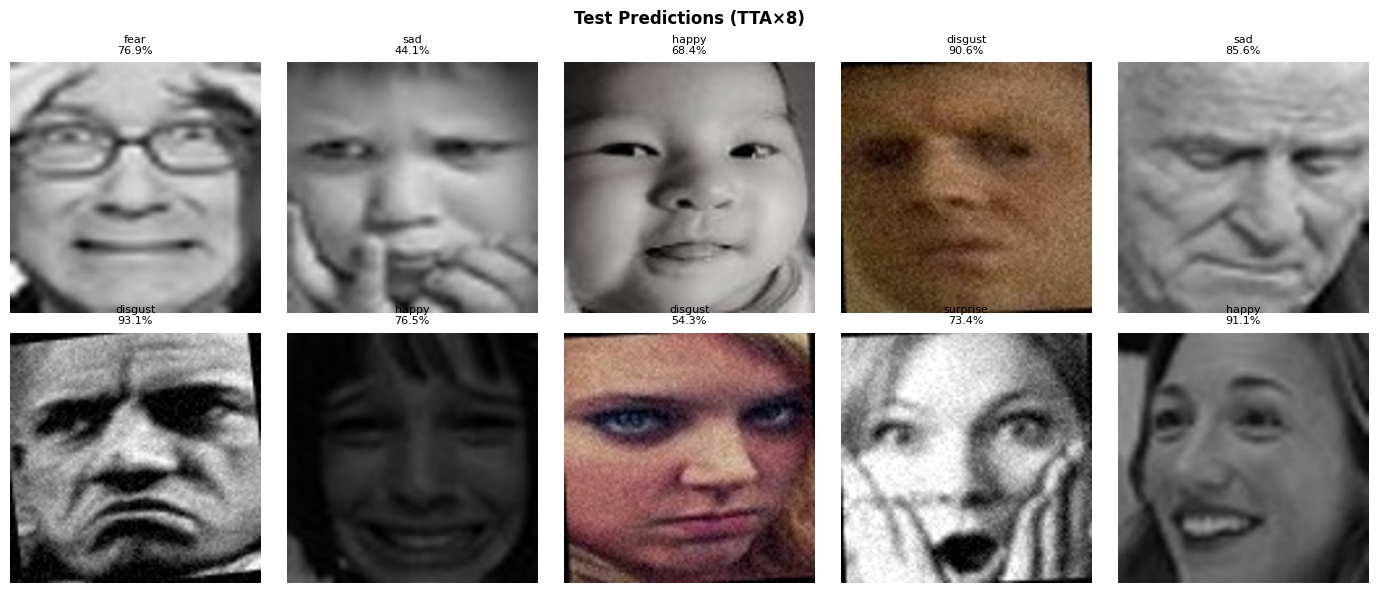

Done 🎉


In [ ]:
 
# CELL 16 — Sample predictions visualisation
 
sample_idx = random.sample(range(len(filenames)), min(10, len(filenames)))
fig, axes  = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.flat, sample_idx):
    img  = Image.open(test_paths[idx]).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    conf = test_probs[idx].max().item() * 100
    ax.imshow(img)
    ax.set_title(f'{test_labels[idx]}\n{conf:.1f}%', fontsize=8)
    ax.axis('off')
plt.suptitle('Test Predictions (TTA×8)', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/test_predictions_sample.png', dpi=150)
plt.show()
print('Done ')